In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn_nd import BlackScholesMultiAssetPINN
from black_scholes.tree.tree import BinomialTree
from config.bs_nd import *

In [2]:
# seed = 7
seed = 0
pinn = BlackScholesMultiAssetPINN(model_config, seed=seed)
pinn.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
# pinn.load(f'../../models/bs_pinn_nd/{seed}.pth')
pinn.load(f'../../models/bs_sobolev_nd/{seed}.pth')


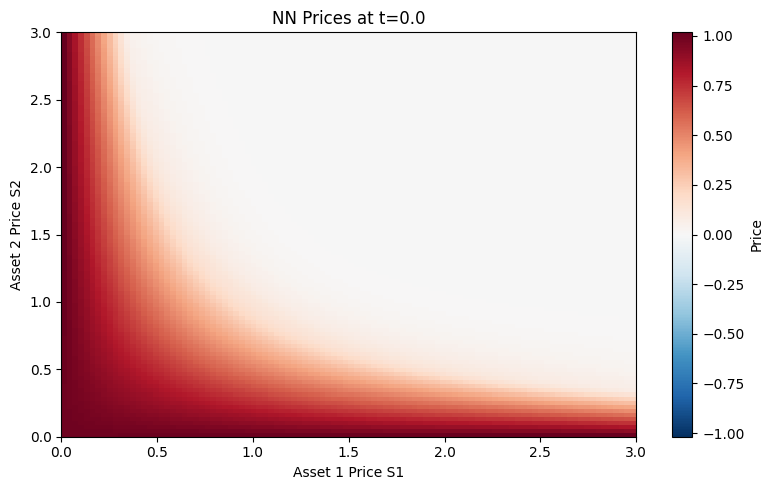

In [3]:
# Heatmap of differences at different T
resolution = 100
S1 = np.linspace(0.0, 3.0, resolution)
S2 = np.linspace(0.0, 3.0, resolution)

# ts = [0.0, 0.25, 0.5, 0.75]
ts = [0.0]

plt.subplots(len(ts), 1, figsize=(8, 5 * len(ts)))
for i, t in enumerate(ts):
    S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
    t_grid = np.full(S1_grid.shape, t)

    nn_prices = pinn.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)

    plt.subplot(len(ts), 1, i + 1)
    vmax = np.abs(nn_prices).max()
    vmin = -vmax
    im = plt.imshow(nn_prices, extent=[S1[0], S1[-1], S2[0], S2[-1]],
                    aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    plt.colorbar(im, label='Price')
    plt.xlabel('Asset 1 Price S1')
    plt.ylabel('Asset 2 Price S2')
    plt.title(f'NN Prices at t={t}')
plt.tight_layout()
plt.show()

In [4]:
cov_matrix = np.outer(sigmas, sigmas) * corr

r_1d = r * 2 + np.sum(np.tril(cov_matrix, k=-1))
sigma_1d = np.sqrt(np.sum(cov_matrix))

bt_1d = BinomialTree(K, r_1d, T, sigma_1d, n_steps=200)


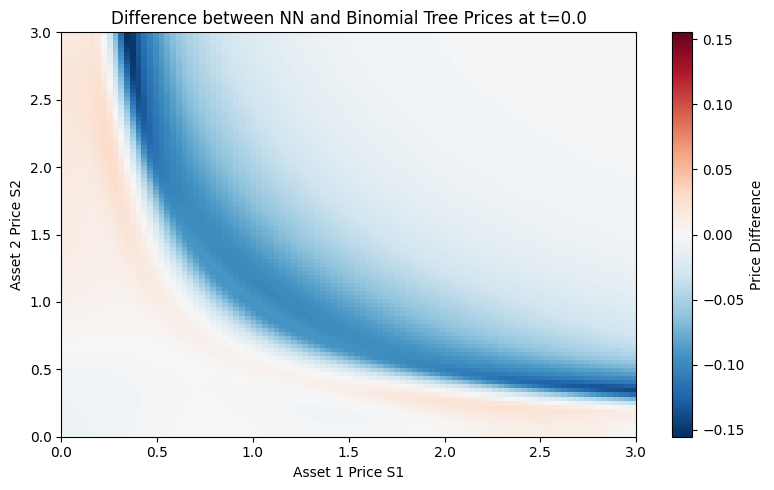

In [5]:
# Heatmap of differences at different T
resolution = 100
S1 = np.linspace(0.0, 3.0, resolution)
S2 = np.linspace(0.0, 3.0, resolution)

# ts = [0.0, 0.25, 0.5, 0.75]
ts = [0.0]

nn_prices_all = np.zeros((len(ts), resolution, resolution))
bt_prices_all = np.zeros((len(ts), resolution, resolution))

plt.subplots(len(ts), 1, figsize=(8, 5 * len(ts)))
for i, t in enumerate(ts):
    S1_grid, S2_grid = np.meshgrid(S1, S2, indexing='ij')
    t_grid = np.full(S1_grid.shape, t)

    nn_prices_all[i, :, :] = pinn.predict(t_grid.flatten(), S1_grid.flatten(), S2_grid.flatten()).detach().numpy().reshape(S1_grid.shape)
    bt_prices_all[i, :, :] = bt_1d.predict(t, (S1_grid * S2_grid).flatten()).reshape(S1_grid.shape)

    diff = nn_prices_all[i, :, :] - bt_prices_all[i, :, :]

    plt.subplot(len(ts), 1, i + 1)
    vmax = np.abs(diff).max()
    vmin = -vmax
    im = plt.imshow(diff, extent=[S1[0], S1[-1], S2[0], S2[-1]],
                    aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
    plt.colorbar(im, label='Price Difference')
    plt.xlabel('Asset 1 Price S1')
    plt.ylabel('Asset 2 Price S2')
    plt.title(f'Difference between NN and Binomial Tree Prices at t={t}')
plt.tight_layout()
plt.show()

### Plots at the money

In [6]:
target = K * 1

Smax = S_maxs[1] / target
resolution = 100

S1s = np.linspace(1 / Smax, Smax, resolution)
S2s = target / S1s

nn_prices_atm = np.array([pinn.predict(0.0, S1, S2).item() for S1, S2 in zip(S1s, S2s)])
bt_price = bt_1d.predict(0.0, target)

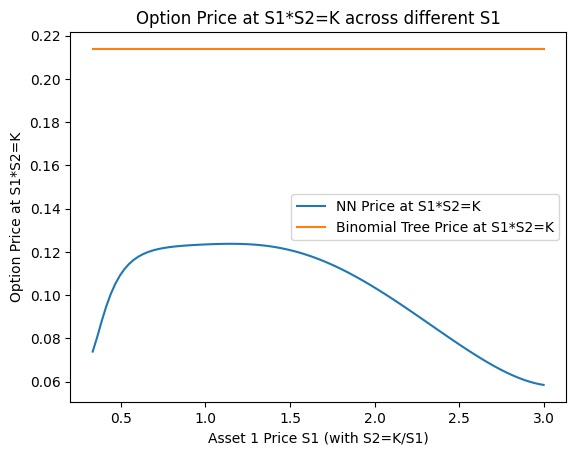

In [7]:
plt.plot(S1s, nn_prices_atm, label='NN Price at S1*S2=K')
plt.plot(S1s, [bt_price] * len(S1s), label='Binomial Tree Price at S1*S2=K')
plt.xlabel('Asset 1 Price S1 (with S2=K/S1)')
plt.ylabel('Option Price at S1*S2=K')
plt.title('Option Price at S1*S2=K across different S1')
plt.legend()
plt.show()

## Free boundary

In [8]:
from utility.continuation_prob import compute_continuation_probs, estimate_continuation_value_nd

In [9]:
resolution = 100
S1s = np.linspace(0, 3, resolution)
S2s = np.linspace(0, 3, resolution)

intrinsics = np.maximum(K - (S1s[:, None] * S2s[None, :]), 0)

continuation_values = np.zeros((resolution, resolution))

for i, S1 in enumerate(S1s):
    for j, S2 in enumerate(S2s):
        S = torch.tensor([S1, S2], dtype=torch.float32)
        continuation_values[i, j] = estimate_continuation_value_nd(pinn.model, 0.0, S, r, sigmas, corr, n_paths=1000, h=0.01, seed=42)


/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:29: RuntimeWarning: divide by zero encountered in divide
  d = (continuation - intrinsics + shift) / intrinsics


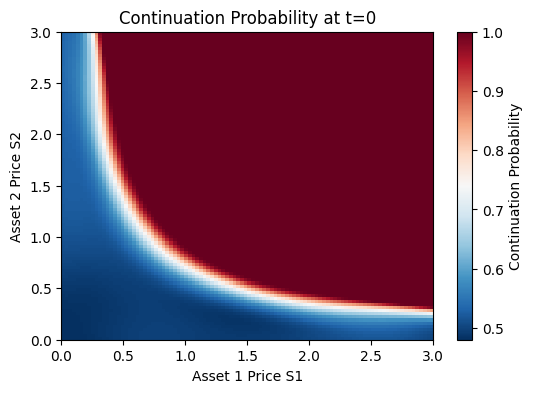

In [10]:
eps = 0.5
cont_probs = compute_continuation_probs(continuation_values, intrinsics, eps=eps, one=0.99, shift=0)

plt.figure(figsize=(6, 4))
plt.imshow(cont_probs, extent=[S1s[0], S1s[-1], S2s[0], S2s[-1]], origin='lower', aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Asset 1 Price S1')
plt.ylabel('Asset 2 Price S2')
plt.title('Continuation Probability at t=0')
plt.show()